17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Test samples: 25000

Training RNN model...

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.6510 - loss: 0.6074 - val_accuracy: 0.7358 - val_loss: 0.5215
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.8547 - loss: 0.3415 - val_accuracy: 0.8092 - val_loss: 0.4339
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9387 - loss: 0.1663 - val_accuracy: 0.8260 - val_loss: 0.4907
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.9761 - loss: 0.0713 - val_accuracy: 0.7636 - val_loss: 0.6773
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9942 - loss: 0.0225 - val_accuracy: 0.8004 - val_loss: 0.7415

Training LSTM model...

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 264ms/step - accuracy: 0.7897 - loss: 0.4423 - val_accuracy: 0.8486 - val_loss: 0.3531
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 274ms/step - accuracy: 0.8997 - loss: 0.2526 - val_accuracy: 0.8684 - val_loss: 0.3082
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 263ms/step - accuracy: 0.9340 - loss

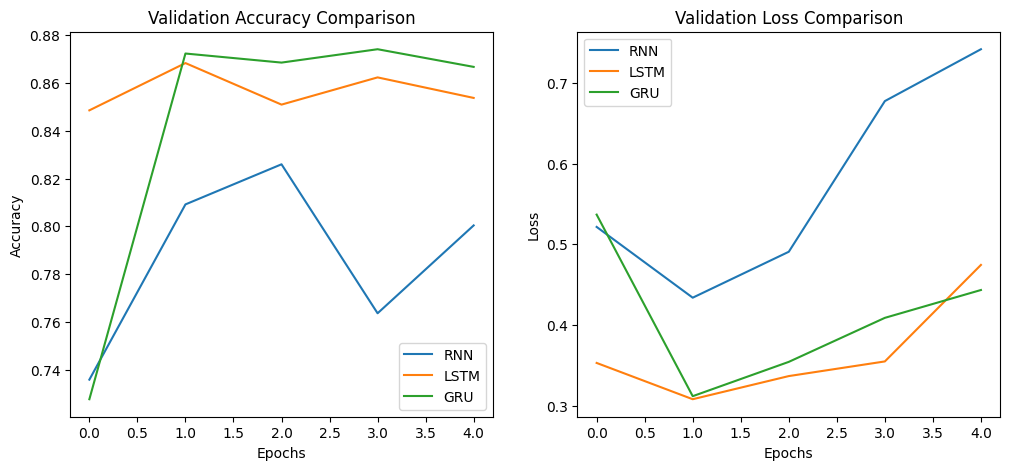


Final Test Accuracy:

RNN Test Accuracy: 0.7748
LSTM Test Accuracy: 0.8640
GRU Test Accuracy: 0.8705

Observations:
- RNN struggles with long-term dependencies (lower accuracy).
- LSTM performs better due to memory cell and gating mechanism.
- GRU performs similar to LSTM but is computationally faster.
- LSTM/GRU show smoother convergence than vanilla RNN.



In [ ]:
# ================================
# Experiment 6: Sequential Models – RNN, LSTM, GRU
# Objective: Compare RNN, LSTM, GRU on IMDb dataset
# ================================

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# ================================
# Step 1: Load and preprocess IMDb dataset
# ================================

# Load dataset (top 10,000 most frequent words)
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

# Pad sequences to same length
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

# ================================
# Function to build models
# ================================

def build_model(model_type):
    model = keras.Sequential()

    # Embedding layer converts word indices to dense vectors
    model.add(layers.Embedding(vocab_size, 128, input_length=max_len))

    # Choose model type
    if model_type == "RNN":
        model.add(layers.SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(layers.LSTM(64))
    elif model_type == "GRU":
        model.add(layers.GRU(64))

    # Output layer for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

# ================================
# Step 2: Train RNN, LSTM, GRU models
# ================================

epochs = 5
batch_size = 64

histories = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type} model...\n")

    model = build_model(model_type)

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    histories[model_type] = history

# ================================
# Step 3: Compare learning curves
# ================================

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
for model_type in histories:
    plt.plot(histories[model_type].history['val_accuracy'], label=model_type)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
for model_type in histories:
    plt.plot(histories[model_type].history['val_loss'], label=model_type)
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ================================
# Step 4: Evaluate models
# ================================

print("\nFinal Test Accuracy:\n")
for model_type in ["RNN", "LSTM", "GRU"]:
    model = build_model(model_type)
    model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{model_type} Test Accuracy: {acc:.4f}")

# ================================
# Observations (for lab record)
# ================================
print("""
Observations:
- RNN struggles with long-term dependencies (lower accuracy).
- LSTM performs better due to memory cell and gating mechanism.
- GRU performs similar to LSTM but is computationally faster.
- LSTM/GRU show smoother convergence than vanilla RNN.
""")

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters
seq_length = 50  # The "memory" distance
input_size = 1
hidden_size = 32
epochs = 200

def generate_data(num_samples, length):
    # Random sequences
    X = np.random.standard_normal((num_samples, length, 1))
    # The target is just the first value of the sequence (Long dependency)
    y = X[:, 0, :]
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X_train, y_train = generate_data(1000, seq_length)

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]) # Predict using the last hidden state

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

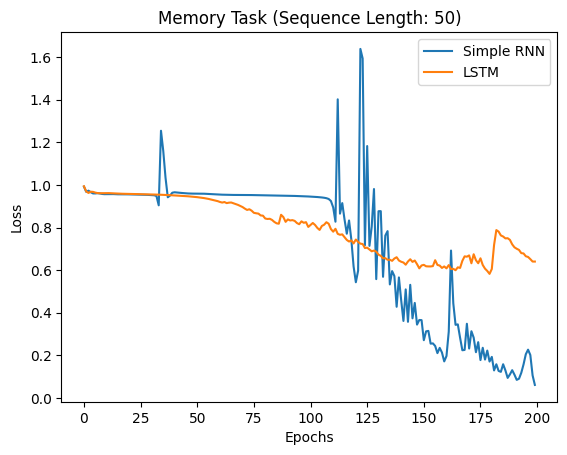

In [ ]:
def train_model(model, X, y):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for epoch in range(epochs):
        outputs = model(X)
        loss = criterion(outputs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

rnn_model = SimpleRNN(input_size, hidden_size)
lstm_model = SimpleLSTM(input_size, hidden_size)

rnn_losses = train_model(rnn_model, X_train, y_train)
lstm_losses = train_model(lstm_model, X_train, y_train)

plt.plot(rnn_losses, label='Simple RNN')
plt.plot(lstm_losses, label='LSTM')
plt.title(f'Memory Task (Sequence Length: {seq_length})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # GRU combines forget and input gates into a single "update gate"
        self.gru = nn.ModuleList([nn.GRU(input_size, hidden_size, batch_first=True)])
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # PyTorch GRU returns (output, hidden)
        out, _ = self.gru[0](x)
        return self.fc(out[:, -1, :])

# Initialize and train
gru_model = SimpleGRU(input_size, hidden_size)
gru_losses = train_model(gru_model, X_train, y_train)

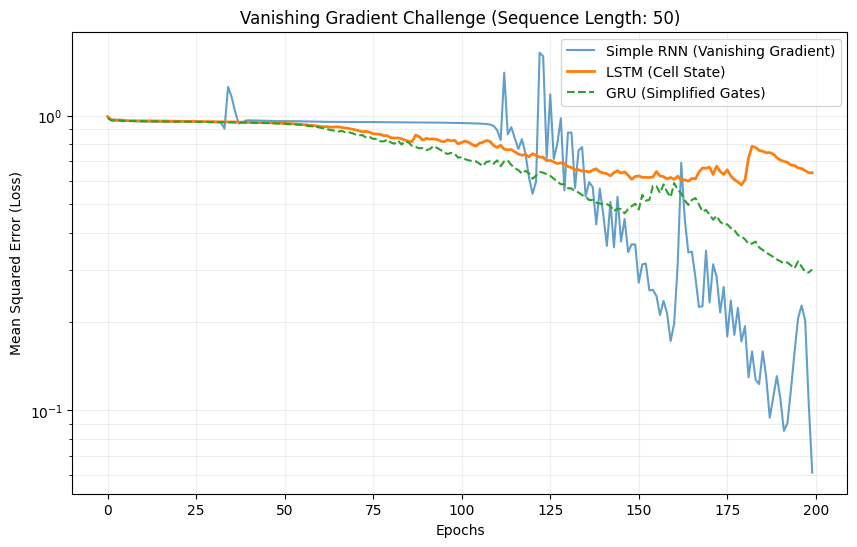

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(rnn_losses, label='Simple RNN (Vanishing Gradient)', alpha=0.7)
plt.plot(lstm_losses, label='LSTM (Cell State)', linewidth=2)
plt.plot(gru_losses, label='GRU (Simplified Gates)', linestyle='--')

plt.title(f'Vanishing Gradient Challenge (Sequence Length: {seq_length})')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.yscale('log') # Log scale helps see the difference when loss is small
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()